# Ejercicio 2 — Transformaciones de una variable normal

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos Matemáticos — Probabilidad y Simulación

---

## Objetivo

Sea $X \sim N(0,1)$. Consideramos dos transformaciones definidas a tramos, $Y = g(X)$ y $Z = h(X)$:

$$g(x) = \begin{cases} -x & x < 0 \\ \alpha x & x \ge 0 \end{cases} \qquad\qquad h(x) = \begin{cases} -x & x < 0 \\ \sqrt{x} & x \ge 0 \end{cases}$$

Se pide:

1. **(2.1)** Obtener por **simulación** la densidad $f_Y(y)$ para $\alpha \in \{-1, -0.5, 0, 0.5, 1\}$, compararla con la normal y discutir para qué valores de $\alpha$ es $Y$ continua (casos $\alpha=0$ y $\alpha=1$).
2. **(2.2)** Para $\alpha > 0$, derivar **analíticamente** $f_Y(y)$ mediante $P(Y<y)$.
3. **(2.3)** Demostrar que $f_Z(z) = \frac{1}{\sqrt{2\pi}}\left(2z\,e^{-z^4/2} + e^{-z^2/2}\right)$ y comprobarlo por simulación.

> **Reproducibilidad.** Se usa una semilla fija y todas las afirmaciones numéricas proceden de las celdas ejecutadas.

### Configuración del entorno

Centralizamos librerías, estilo, constantes, la muestra de $X\sim N(0,1)$ y las funciones del problema.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.stats import norm, kstest

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
})

# ── Constantes del problema ──────────────────────────────────────────────────
SEED   = 42
N_SIM  = 1_000_000               # muchas muestras ⇒ histogramas nítidos
ALPHAS = [-1.0, -0.5, 0.0, 0.5, 1.0]

# ── Muestra base X ~ N(0,1) (se reutiliza en todo el notebook) ───────────────
rng = np.random.default_rng(SEED)
X = rng.standard_normal(N_SIM)

# ── Funciones del problema ───────────────────────────────────────────────────
def phi(x):
    """Densidad N(0,1)."""
    return np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)

Phi = norm.cdf                    # función de distribución N(0,1)

def g(x, alpha):
    """Y = g(X): -x si x<0 ; alpha·x si x>=0."""
    return np.where(x < 0, -x, alpha * x)

def h(x):
    """Z = h(X): -x si x<0 ; sqrt(x) si x>=0."""
    return np.where(x < 0, -x, np.sqrt(np.clip(x, 0, None)))

print(f"X ~ N(0,1) con {N_SIM:,} muestras (semilla {SEED})")
print(f"media muestral = {X.mean():.4f}, desv. típica = {X.std():.4f}")

X ~ N(0,1) con 1,000,000 muestras (semilla 42)
media muestral = 0.0001, desv. típica = 1.0005


---
## Apartado 2.1 — Densidad de $Y=g(X)$ por simulación

### Cómo actúa la transformación

$g$ trata por separado las dos mitades de $X$ (cada una con probabilidad $1/2$):

- **Rama $x<0$:** $Y=-x>0$. Esta mitad **siempre** se envía al semieje positivo, sea cual sea $\alpha$.
- **Rama $x\ge 0$:** $Y=\alpha x$. El signo y la escala dependen de $\alpha$:
  - $\alpha>0\Rightarrow Y\ge 0$ (toda la masa en $y\ge 0$).
  - $\alpha<0\Rightarrow Y\le 0$ (esta mitad va al semieje negativo).
  - $\alpha=0\Rightarrow Y=0$ para **todo** $x\ge 0$: aparece un **átomo** en $0$ con probabilidad $1/2$.

Dos casos notables que la simulación debe reflejar:
- $\alpha=-1$: entonces $g(x)=-x$ en **ambas** ramas, luego $Y=-X\sim N(0,1)$ exactamente.
- $\alpha=1$: entonces $g(x)=|x|$, luego $Y=|X|$ es una **media normal** (half-normal).

Simulamos $Y$ para cada $\alpha$, estimamos su densidad con un histograma y la comparamos con $N(0,1)$.

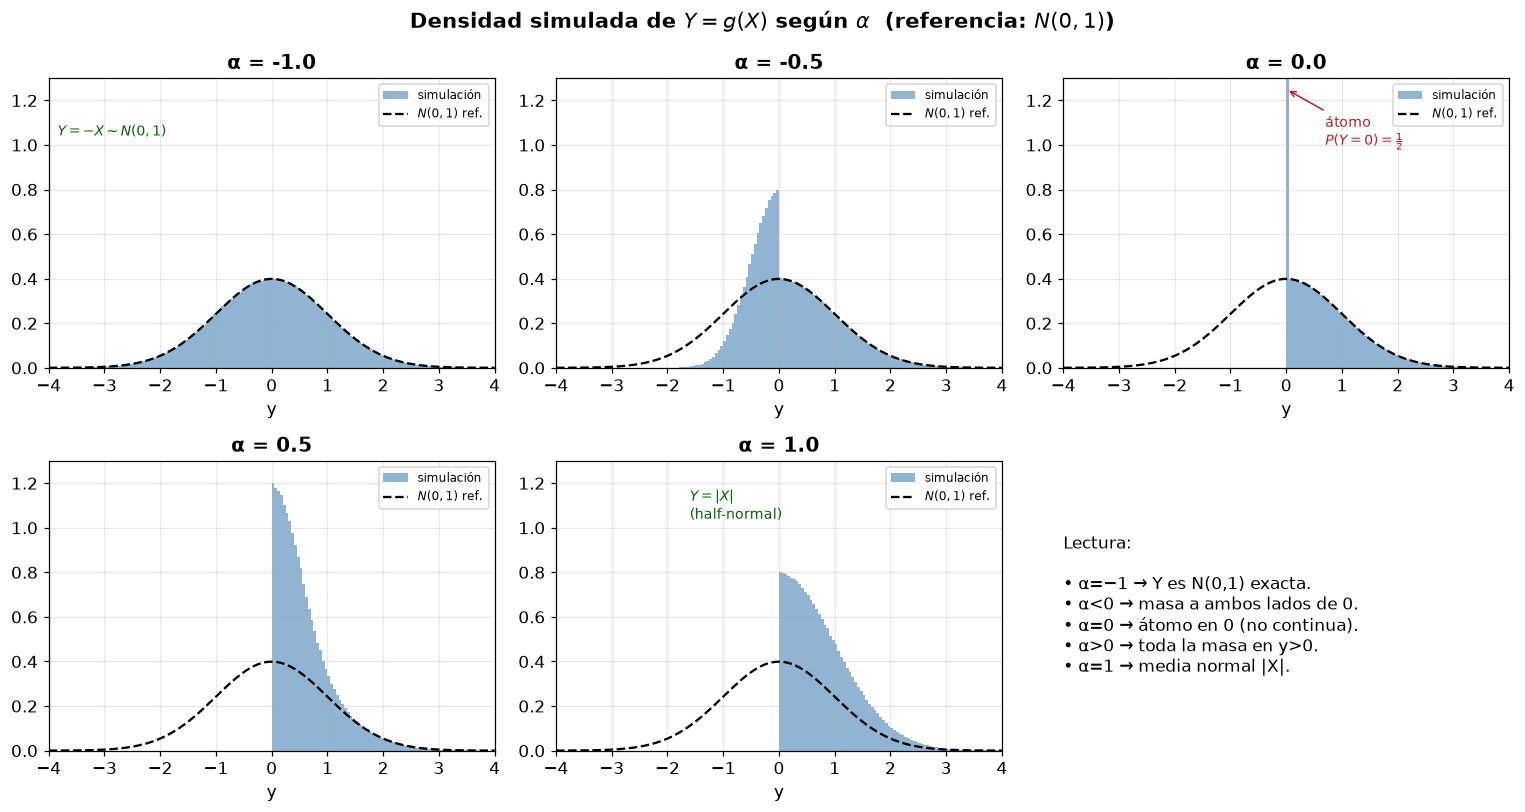

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
fig.suptitle("Densidad simulada de $Y=g(X)$ según $\\alpha$  (referencia: $N(0,1)$)",
             fontsize=14, fontweight="bold")
axes = axes.ravel()
xx = np.linspace(-4, 4, 600)

for ax, a in zip(axes, ALPHAS):
    Y = g(X, a)
    ax.hist(Y, bins=160, range=(-4, 4), density=True, alpha=0.6,
            color="steelblue", label="simulación")
    ax.plot(xx, phi(xx), "k--", lw=1.5, label="$N(0,1)$ ref.")
    ax.set(title=f"α = {a}", xlim=(-4, 4), ylim=(0, 1.3), xlabel="y")
    ax.legend(fontsize=8, loc="upper right")
    if a == 0.0:                       # señalar el átomo (la barra se sale del eje)
        ax.annotate("átomo\n$P(Y=0)=\\frac{1}{2}$", xy=(0, 1.25), xytext=(0.7, 1.0),
                    fontsize=9, color="firebrick",
                    arrowprops=dict(arrowstyle="->", color="firebrick"))
    if a == -1.0:
        ax.text(0.02, 0.80, "$Y=-X\\sim N(0,1)$", transform=ax.transAxes,
                fontsize=9, color="darkgreen")
    if a == 1.0:
        ax.text(0.30, 0.80, "$Y=|X|$\n(half-normal)", transform=ax.transAxes,
                fontsize=9, color="darkgreen")

axes[5].axis("off")                     # 6º panel: resumen textual
axes[5].text(0.0, 0.5,
    "Lectura:\n\n"
    "• α=−1 → Y es N(0,1) exacta.\n"
    "• α<0 → masa a ambos lados de 0.\n"
    "• α=0 → átomo en 0 (no continua).\n"
    "• α>0 → toda la masa en y>0.\n"
    "• α=1 → media normal |X|.",
    fontsize=11, va="center")

plt.tight_layout()
plt.savefig("resultados/grafico_2a_densidades_Y.png", dpi=150, bbox_inches="tight")
plt.show()

### Continuidad de $Y$: evidencia cuantitativa

Una variable es (absolutamente) **continua** si no tiene átomos. El único valor de $\alpha$ que crea un átomo es $\alpha=0$ (la rama $x\ge 0$ colapsa en $y=0$). Lo medimos, y de paso confirmamos numéricamente el caso $\alpha=-1$.

In [3]:
print("Proporción de masa exactamente en Y=0 (átomo) según α:")
for a in ALPHAS:
    p0 = np.mean(g(X, a) == 0.0)
    etiqueta = "  ← ÁTOMO ⇒ NO continua" if p0 > 1e-3 else ""
    print(f"  α = {a:>4}:  P(Y=0) = {p0:.4f}{etiqueta}")

# Caso α=-1: contraste formal con N(0,1) mediante Kolmogórov–Smirnov
ks_m1 = kstest(g(X, -1.0), "norm")
print(f"\nα = -1:  test KS de Y frente a N(0,1) → D = {ks_m1.statistic:.5f} "
      f"(distancia ínfima ⇒ Y ≡ N(0,1))")

Proporción de masa exactamente en Y=0 (átomo) según α:
  α = -1.0:  P(Y=0) = 0.0000
  α = -0.5:  P(Y=0) = 0.0000
  α =  0.0:  P(Y=0) = 0.4997  ← ÁTOMO ⇒ NO continua
  α =  0.5:  P(Y=0) = 0.0000
  α =  1.0:  P(Y=0) = 0.0000



α = -1:  test KS de Y frente a N(0,1) → D = 0.00066 (distancia ínfima ⇒ Y ≡ N(0,1))


### Respuesta al apartado 2.1

- **¿Para qué $\alpha$ es $Y$ continua?** Para **todo $\alpha\neq 0$**. La rama $x<0$ aporta una densidad suave en $y>0$ y la rama $x\ge 0$ (si $\alpha\neq 0$) reparte su masa de forma continua (en $y>0$ si $\alpha>0$, en $y<0$ si $\alpha<0$). No hay átomos.
- **Caso $\alpha=0$:** la rama $x\ge 0$ envía toda su probabilidad ($1/2$) al punto $y=0$. Aparece un **átomo** $P(Y=0)=\tfrac12$, de modo que $Y$ es **mixta** (no continua): una masa puntual en $0$ más una parte continua $\phi(y)$ en $y>0$.
- **Caso $\alpha=1$:** $g(x)=|x|$, así que $Y=|X|$ es una **media normal**; ambas ramas se suman y dan la densidad continua $f_Y(y)=2\phi(y)$ en $y>0$ (lo confirmamos en 2.2).
- **Comparación con la normal:** solo $\alpha=-1$ reproduce $N(0,1)$ (porque $g(x)=-x$); para el resto la densidad de $Y$ difiere claramente de la normal.

---
## Apartado 2.2 — Densidad analítica de $Y$ para $\alpha>0$

Para $\alpha>0$ ambas ramas envían la masa a $y>0$, luego $Y$ **solo toma valores positivos**. Seguimos la sugerencia: escribir $P(Y<y)$ y derivar.

Para $y>0$, el suceso $\{Y<y\}=\{g(X)<y\}$ se descompone según la rama:

$$\{Y<y\} = \underbrace{\{x<0,\ -x<y\}}_{-y<x<0} \ \cup\ \underbrace{\{x\ge 0,\ \alpha x<y\}}_{0\le x<y/\alpha} = \left\{-y < X < \tfrac{y}{\alpha}\right\}$$

Por tanto,

$$P(Y<y) = \Phi\!\left(\tfrac{y}{\alpha}\right) - \Phi(-y) = \Phi\!\left(\tfrac{y}{\alpha}\right) + \Phi(y) - 1$$

donde hemos usado $\Phi(-y)=1-\Phi(y)$. Derivando respecto de $y$ (regla de la cadena):

$$\boxed{\,f_Y(y) = \phi(y) + \frac{1}{\alpha}\,\phi\!\left(\frac{y}{\alpha}\right) = \frac{1}{\sqrt{2\pi}}\left(e^{-y^2/2} + \frac{1}{\alpha}\,e^{-y^2/(2\alpha^2)}\right), \quad y>0\,}$$

**Comprobaciones:** el primer término $\phi(y)$ procede de la rama $x<0$ (con jacobiano $1$) y el segundo $\tfrac1\alpha\phi(y/\alpha)$ de la rama $x\ge 0$ (jacobiano $1/\alpha$). Para $\alpha=1$ se obtiene $f_Y(y)=2\phi(y)$, la **media normal** anticipada. La densidad integra $1$ porque cada término aporta $1/2$.

In [4]:
def fY_pos(y, alpha):
    """Densidad analítica de Y para alpha>0 (soporte y>0)."""
    y = np.asarray(y, float)
    return np.where(y > 0, phi(y) + (1/alpha) * phi(y/alpha), 0.0)

# Verificación 1: la densidad integra 1 en (0, ∞)
print("Verificación de la densidad analítica (α>0):")
for a in [0.5, 1.0]:
    val, _ = integrate.quad(lambda y: fY_pos(y, a), 0, np.inf)
    # Verificación 2: distancia KS entre la simulación y la CDF teórica
    F = lambda y, a=a: Phi(y/a) + Phi(y) - 1
    ks = kstest(g(X, a), F)
    print(f"  α = {a}:  ∫₀^∞ fY dy = {val:.6f}   |   KS vs simulación: D = {ks.statistic:.5f}")

Verificación de la densidad analítica (α>0):


  α = 0.5:  ∫₀^∞ fY dy = 1.000000   |   KS vs simulación: D = 0.00092


  α = 1.0:  ∫₀^∞ fY dy = 1.000000   |   KS vs simulación: D = 0.00059


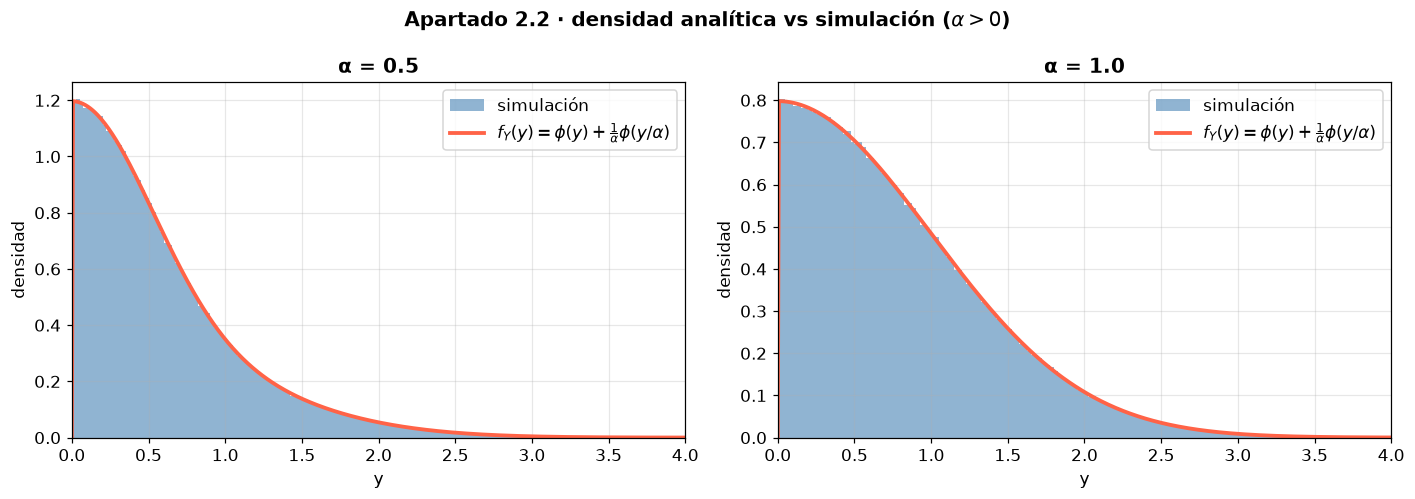

In [5]:
# Verificación visual: histograma simulado vs densidad analítica fY (α>0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
yy = np.linspace(0, 4, 500)
for ax, a in zip(axes, [0.5, 1.0]):
    Y = g(X, a)   # para α>0 toda la masa está en y>0, así que density=True normaliza bien
    ax.hist(Y, bins=160, range=(0, 4), density=True, alpha=0.6,
            color="steelblue", label="simulación")
    ax.plot(yy, fY_pos(yy, a), color="tomato", lw=2.5,
            label=r"$f_Y(y)=\phi(y)+\frac{1}{\alpha}\phi(y/\alpha)$")
    ax.set(title=f"α = {a}", xlim=(0, 4), xlabel="y", ylabel="densidad")
    ax.legend()
fig.suptitle("Apartado 2.2 · densidad analítica vs simulación ($\\alpha>0$)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("resultados/grafico_2b_fY_analitica.png", dpi=150, bbox_inches="tight")
plt.show()

El histograma simulado se ajusta a la curva analítica, confirmando la fórmula. Obsérvese que para $\alpha=1$ se recupera la media normal $f_Y(y)=2\phi(y)$ y que, al ser $\alpha<1$, el segundo término $\tfrac1\alpha\phi(y/\alpha)$ concentra más masa cerca de $0$ (la rama $x\ge0$ "comprime" hacia el origen).

---
## Apartado 2.3 — Densidad de $Z=h(X)$

Ahora $h(x)=-x$ si $x<0$ y $h(x)=\sqrt{x}$ si $x\ge 0$. Ambas ramas producen valores **no negativos**, así que $Z>0$ (salvo el punto $X=0$, de probabilidad nula). Procedemos igual que en 2.2: $P(Z<z)$ y derivar.

Para $z>0$:

$$\{Z<z\} = \underbrace{\{x<0,\ -x<z\}}_{-z<x<0} \ \cup\ \underbrace{\{x\ge 0,\ \sqrt{x}<z\}}_{0\le x<z^2} = \left\{-z < X < z^2\right\}$$

$$P(Z<z) = \Phi(z^2) - \Phi(-z) = \Phi(z^2) + \Phi(z) - 1$$

Derivando respecto de $z$ (la rama $\sqrt{x}$ da $\tfrac{d}{dz}\Phi(z^2)=2z\,\phi(z^2)$):

$$f_Z(z) = 2z\,\phi(z^2) + \phi(z) = \frac{1}{\sqrt{2\pi}}\left(2z\,e^{-z^4/2} + e^{-z^2/2}\right), \quad z>0$$

que es exactamente la expresión del enunciado. $\blacksquare$

El primer término $2z\,\phi(z^2)$ proviene de la rama $\sqrt{x}$ (jacobiano $2z$) y el segundo $\phi(z)$ de la rama $-x$ (jacobiano $1$). Lo comprobamos por simulación.

In [6]:
def fZ(z):
    """Densidad analítica de Z (soporte z>0)."""
    z = np.asarray(z, float)
    return np.where(z > 0, (2*z*phi(z**2) + phi(z)), 0.0)

Z = h(X)

# Verificaciones numéricas
int_fZ, _ = integrate.quad(fZ, 0, np.inf)
F_Z = lambda z: Phi(z**2) + Phi(z) - 1            # CDF teórica
ks_Z = kstest(Z, F_Z)
print("Comprobación de f_Z:")
print(f"  soporte: min(Z) = {Z.min():.4f}  (Z > 0) ✓")
print(f"  ∫₀^∞ f_Z(z) dz = {int_fZ:.6f}  (debe ser 1) ✓")
print(f"  test KS simulación vs F_Z teórica → D = {ks_Z.statistic:.5f} (ínfimo) ✓")

Comprobación de f_Z:
  soporte: min(Z) = 0.0000  (Z > 0) ✓
  ∫₀^∞ f_Z(z) dz = 1.000000  (debe ser 1) ✓
  test KS simulación vs F_Z teórica → D = 0.00081 (ínfimo) ✓


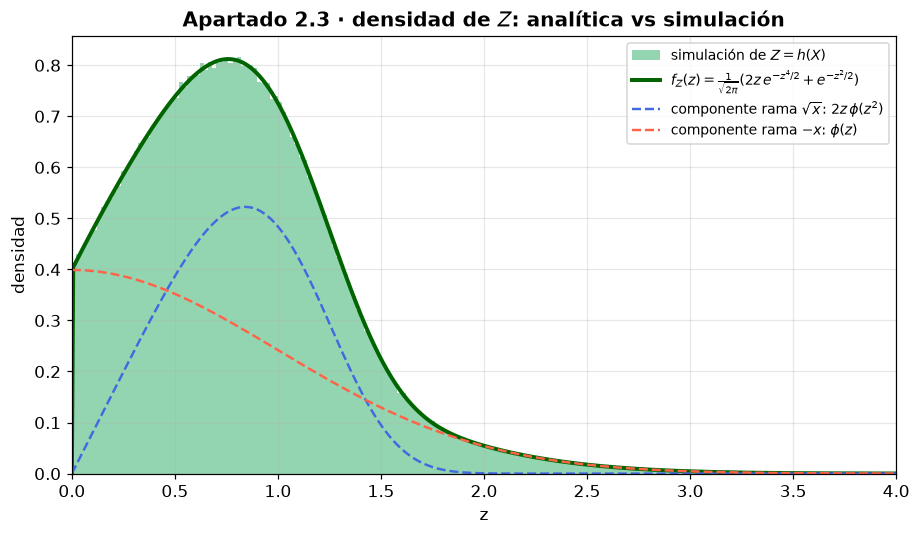

In [7]:
# Verificación visual: histograma de Z vs densidad analítica y sus dos componentes
zz = np.linspace(0, 4, 600)
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(Z, bins=200, range=(0, 4), density=True, alpha=0.55,
        color="mediumseagreen", label="simulación de $Z=h(X)$")
ax.plot(zz, fZ(zz), color="darkgreen", lw=2.6,
        label=r"$f_Z(z)=\frac{1}{\sqrt{2\pi}}(2z\,e^{-z^4/2}+e^{-z^2/2})$")
ax.plot(zz, 2*zz*phi(zz**2), color="royalblue", lw=1.6, ls="--",
        label=r"componente rama $\sqrt{x}$: $2z\,\phi(z^2)$")
ax.plot(zz, phi(zz), color="tomato", lw=1.6, ls="--",
        label=r"componente rama $-x$: $\phi(z)$")
ax.set(title="Apartado 2.3 · densidad de $Z$: analítica vs simulación",
       xlim=(0, 4), xlabel="z", ylabel="densidad")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("resultados/grafico_2c_fZ.png", dpi=150, bbox_inches="tight")
plt.show()

La curva analítica se superpone con precisión al histograma. Se aprecia el **doble origen** de la densidad: el pico cerca de $z\approx 0.6$–$1$ lo aporta la rama $\sqrt{x}$ (término $2z\,e^{-z^4/2}$) y la cola lo aporta la rama $-x$ (término $e^{-z^2/2}$, media normal).

---
## Conclusiones

> Todas las afirmaciones numéricas proceden de las celdas ejecutadas (semilla fija).

**Apartado 2.1 — $f_Y$ por simulación y continuidad.**
- $Y$ es una variable **continua para todo $\alpha\neq 0$**.
- En $\alpha=0$ la rama $x\ge 0$ colapsa en $y=0$ y crea un **átomo** $P(Y=0)=\tfrac12$: $Y$ es **mixta**, no continua.
- En $\alpha=1$, $Y=|X|$ es una **media normal**.
- Frente a la normal, solo $\alpha=-1$ reproduce $N(0,1)$ (pues $g(x)=-x$); el test KS confirma distancia ínfima.

**Apartado 2.2 — $f_Y$ analítica para $\alpha>0$.** Vía $P(Y<y)=\Phi(y/\alpha)+\Phi(y)-1$,
$$f_Y(y) = \phi(y) + \tfrac{1}{\alpha}\,\phi\!\left(\tfrac{y}{\alpha}\right),\quad y>0.$$
Integra $1$ y el test KS frente a la simulación da distancia ínfima.

**Apartado 2.3 — $f_Z$.** Vía $P(Z<z)=\Phi(z^2)+\Phi(z)-1$,
$$f_Z(z) = 2z\,\phi(z^2) + \phi(z) = \tfrac{1}{\sqrt{2\pi}}\left(2z\,e^{-z^4/2}+e^{-z^2/2}\right),\quad z>0,$$
tal como pedía el enunciado. La simulación lo confirma: $Z>0$, la densidad integra $1$ y el ajuste histograma–curva es excelente.

**Idea transversal.** Para transformaciones definidas a tramos, el método robusto es **acumular probabilidad** ($P(\cdot<v)$) sumando la contribución de cada rama y **derivar**; cada rama monótona aporta un término $\phi(\cdot)\,|\text{jacobiano}|$. La simulación (histograma + KS) sirve como verificación independiente de la deducción analítica.